# Hidden Markov Models for Named Entity Recognition (NER)

In this notebook we apply an HMM to **Named Entity Recognition (NER)** using the CoNLL 2002 corpus in Spanish.

Since the states (NER tags) are **known during training**, we estimate the model parameters directly by **counting** (supervised maximum likelihood) and pass them to `hmmlearn` to perform decoding with **Viterbi**.

## The model

An HMM for NER has:
- **Hidden states**: NER tags (`O`, `B-PER`, `I-PER`, `B-LOC`, ...)
- **Observations**: words in the text
- **Parameters**:
  - $\pi$: initial state probabilities
  - $A$: transition matrix between states
  - $B$: emission matrix (probability of each word given each state)

Since we know the tags, estimation is simply count and normalize.

## Setup

In [1]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install nltk
!pip install hmmlearn

## Loading the corpus

In [2]:
import nltk
nltk.download('conll2002', quiet=True)

from nltk.corpus import conll2002

train_sents = list(conll2002.iob_sents('esp.train'))
test_sents  = list(conll2002.iob_sents('esp.testa'))

print(f'Training sentences: {len(train_sents)}')
print(f'Test sentences:     {len(test_sents)}')
print()
print('Example sentence (token, POS, NER tag):')
print(train_sents[0])

Training sentences: 8323
Test sentences:     1915

Example sentence (token, POS, NER tag):
[('Melbourne', 'NP', 'B-LOC'), ('(', 'Fpa', 'O'), ('Australia', 'NP', 'B-LOC'), (')', 'Fpt', 'O'), (',', 'Fc', 'O'), ('25', 'Z', 'O'), ('may', 'NC', 'O'), ('(', 'Fpa', 'O'), ('EFE', 'NC', 'B-ORG'), (')', 'Fpt', 'O'), ('.', 'Fp', 'O')]


Each sentence is a list of tuples `(token, POS, NER_tag)`. We keep only tokens and NER tags.

In [3]:
def extract_tokens_labels(sents):
    tokens_per_sent = [[tok for tok, pos, ner in s] for s in sents]
    labels_per_sent = [[ner for tok, pos, ner in s] for s in sents]
    return tokens_per_sent, labels_per_sent

train_tokens, train_labels = extract_tokens_labels(train_sents)
test_tokens,  test_labels  = extract_tokens_labels(test_sents)

print("Training tokens", sum(len(sublist) for sublist in train_tokens))
print("Test tokens", sum(len(sublist) for sublist in test_tokens))

Training tokens 264715
Test tokens 52923


In [4]:
from collections import Counter

all_labels   = [lab for seq in train_labels for lab in seq]
label_counts = Counter(all_labels)

print('Tags and frequencies:')
for lab, cnt in sorted(label_counts.items(), key=lambda x: -x[1]):
    print(f'  {lab:12s}  {cnt:7d}')

Tags and frequencies:
  O              231920
  B-ORG            7390
  I-ORG            4992
  B-LOC            4913
  B-PER            4321
  I-PER            3903
  I-MISC           3212
  B-MISC           2173
  I-LOC            1891


## Building vocabularies

To keep the model manageable, we replace infrequent words with a special `<UNK>` token.

In [5]:
import numpy as np

MIN_FREQ = 2  # words with frequency < MIN_FREQ are replaced by the unknown word token <UNK>

word_counts = Counter(tok for seq in train_tokens for tok in seq)

vocab    = ['<UNK>'] + [w for w, c in word_counts.items() if c >= MIN_FREQ]
word2idx = {w: i for i, w in enumerate(vocab)}

labels    = sorted(set(all_labels))
label2idx = {l: i for i, l in enumerate(labels)}
idx2label = {i: l for l, i in label2idx.items()}

print(f'Vocabulary size: {len(vocab)} words')
print(f'Number of tags:  {len(labels)}')
print(f'Tags: {labels}')

Vocabulary size: 13492 words
Number of tags:  9
Tags: ['B-LOC', 'B-MISC', 'B-ORG', 'B-PER', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER', 'O']


## Supervised parameter estimation

With known states, the three HMM parameters are estimated by counting:
$$\pi_i = \frac{\text{\# sentences starting with state } i}{\text{\# sentences}}$$

$$A_{ij} = \frac{\text{\# transitions } i \to j}{\text{\# times state } i \text{ appears}}$$

$$B_{ik} = \frac{\text{\# times state } i \text{ emits word } k}{\text{\# times state } i \text{ appears}}$$

In [6]:
n_states = len(labels)
n_obs    = len(vocab)

pi_counts = np.zeros(n_states)
A_counts  = np.zeros((n_states, n_states))
B_counts  = np.zeros((n_states, n_obs))

for tokens_seq, labels_seq in zip(train_tokens, train_labels):
    # Initial probabilities
    pi_counts[label2idx[labels_seq[0]]] += 1

    for t, (tok, lab) in enumerate(zip(tokens_seq, labels_seq)):
        s = label2idx[lab]
        w = word2idx.get(tok, 0)  # 0 = <UNK>

        # Emission
        B_counts[s, w] += 1

        # Transition
        if t + 1 < len(labels_seq):
            s_next = label2idx[labels_seq[t + 1]]
            A_counts[s, s_next] += 1

print('Counts computed.')
print(f'  pi_counts shape: {pi_counts.shape}')
print(f'  A_counts  shape: {A_counts.shape}')
print(f'  B_counts  shape: {B_counts.shape}')

Counts computed.
  pi_counts shape: (9,)
  A_counts  shape: (9, 9)
  B_counts  shape: (9, 13492)


In [7]:
def normalize_rows(counts):
    """Normalize counts to probabilities row by row.
    Rows that sum to zero (unseen states) receive a uniform distribution."""
    totals     = counts.sum(axis=-1, keepdims=True)
    safe       = np.where(totals == 0, 1, totals)
    probs      = counts / safe
    zero_rows  = (totals.squeeze() == 0)
    probs[zero_rows] = 1.0 / counts.shape[-1]
    return probs

pi = normalize_rows(pi_counts)
A  = normalize_rows(A_counts)
B  = normalize_rows(B_counts)

print('Parameters normalized.')

Parameters normalized.


### Inspecting the parameters

Before building the model, let's verify that the parameters make linguistic sense.

In [8]:
import pandas as pd

pi_df = pd.Series(pi, index=labels).sort_values(ascending=False)
print('Initial state probabilities (pi):')
print(pi_df.to_string())

Initial state probabilities (pi):
O         0.799832
B-LOC     0.076054
B-PER     0.072330
B-ORG     0.035564
B-MISC    0.016100
I-LOC     0.000120
I-MISC    0.000000
I-ORG     0.000000
I-PER     0.000000


In [9]:
A_df = pd.DataFrame(A, index=labels, columns=labels)
print('Transition matrix A (rows = origin state, columns = destination state):')
print(A_df.round(3).to_string())

Transition matrix A (rows = origin state, columns = destination state):
        B-LOC  B-MISC  B-ORG  B-PER  I-LOC  I-MISC  I-ORG  I-PER      O
B-LOC   0.005   0.000  0.000  0.003  0.217   0.000  0.000  0.000  0.775
B-MISC  0.003   0.000  0.005  0.003  0.000   0.578  0.000  0.000  0.412
B-ORG   0.004   0.000  0.000  0.006  0.000   0.000  0.303  0.000  0.686
B-PER   0.001   0.000  0.000  0.000  0.000   0.000  0.000  0.666  0.333
I-LOC   0.001   0.000  0.000  0.000  0.436   0.000  0.000  0.000  0.563
I-MISC  0.001   0.002  0.001  0.002  0.000   0.610  0.000  0.000  0.384
I-ORG   0.000   0.000  0.001  0.004  0.000   0.000  0.551  0.000  0.444
I-PER   0.006   0.000  0.000  0.002  0.000   0.000  0.000  0.263  0.729
O       0.019   0.009  0.032  0.016  0.000   0.000  0.000  0.000  0.924


In [10]:
TOP_N = 8
print(f'Top {TOP_N} most probable words per tag:')
for lab in labels:
    s         = label2idx[lab]
    top_idx   = np.argsort(B[s])[::-1][:TOP_N]
    top_words = [vocab[i] for i in top_idx]
    print(f'  {lab:12s}: {top_words}')

Top 8 most probable words per tag:
  B-LOC       : ['<UNK>', 'Madrid', 'España', 'Barcelona', 'París', 'La', 'San', 'Francia']
  B-MISC      : ['<UNK>', '"', 'Liga', 'Copa', 'Plan', 'Internet', 'Interior', 'Juegos']
  B-ORG       : ['EFE', '<UNK>', 'Gobierno', 'PP', 'Real', 'Ayuntamiento', 'Comisión', 'EFECOM']
  B-PER       : ['<UNK>', 'José', 'Juan', 'Manuel', 'Francisco', 'Luis', 'Carlos', 'Miguel']
  I-LOC       : ['de', '<UNK>', 'la', 'del', 'Janeiro', 'Sebastián', 'York', 'Vasco']
  I-MISC      : ['de', '<UNK>', '"', 'del', 'la', 'Campeones', 'en', '2000']
  I-ORG       : ['de', '<UNK>', 'del', 'la', 'Madrid', 'Nacional', '"', 'Europea']
  I-PER       : ['<UNK>', 'de', 'María', 'la', 'Fernández', 'González', 'del', 'Alvarez']
  O           : ['de', ',', 'la', '<UNK>', 'que', '.', 'el', 'en']


## Building the model with hmmlearn

We use `CategoricalHMM`, appropriate when observations are discrete categories (words).

The key trick: `init_params=''` and `params=''` tell hmmlearn not to modify the parameters we provide: no Baum-Welch, no random initialization.

In [11]:
from hmmlearn import hmm

model = hmm.CategoricalHMM(n_components=n_states, init_params='', params='')

# Initialize model probabilities
model.startprob_    = pi
model.transmat_     = A
model.emissionprob_ = B

print('Model built with count-estimated parameters.')
print(f'  Number of states:  {model.n_components}')
print(f'  Vocabulary size:   {model.emissionprob_.shape[1]}')

Model built with count-estimated parameters.
  Number of states:  9
  Vocabulary size:   13492


## Decoding with Viterbi

Given the trained model, for each test sentence we find the most probable tag sequence:

$$\hat{y} = \arg\max_y P(y \mid x)$$

`model.predict()` implements the **Viterbi algorithm** internally.

In [12]:
def predict_sentence(tokens):
    """Return predicted tags for a sequence of tokens."""
    obs       = np.array([[word2idx.get(tok, 0)] for tok in tokens])
    state_ids = model.predict(obs)
    return [idx2label[s] for s in state_ids]

# Example on the first test sentence
i=0
ex_tokens = test_tokens[i]
ex_gold   = test_labels[i]
ex_pred   = predict_sentence(ex_tokens)

print(f'{"Token":20s} {"Gold":12s} {"Pred":12s}')
print('-' * 46)
for tok, gold, pred in zip(ex_tokens, ex_gold, ex_pred):
    mark = 'OK' if gold == pred else 'WRONG'
    print(f'{tok:20s} {gold:12s} {pred:12s} {mark}')

Token                Gold         Pred        
----------------------------------------------
Sao                  B-LOC        B-LOC        OK
Paulo                I-LOC        I-LOC        OK
(                    O            O            OK
Brasil               B-LOC        B-LOC        OK
)                    O            O            OK
,                    O            O            OK
23                   O            O            OK
may                  O            O            OK
(                    O            O            OK
EFECOM               B-ORG        B-ORG        OK
)                    O            O            OK
.                    O            O            OK


## Evaluation

In [13]:
all_gold = []
all_pred = []

for tokens, labels_seq in zip(test_tokens, test_labels):
    all_gold.extend(labels_seq)
    all_pred.extend(predict_sentence(tokens))

In [14]:
from sklearn.metrics import classification_report

print('Full report (including O):')
print(classification_report(all_gold, all_pred, labels=labels, zero_division=0))

Full report (including O):
              precision    recall  f1-score   support

       B-LOC       0.68      0.74      0.71       984
      B-MISC       0.54      0.42      0.47       445
       B-ORG       0.86      0.56      0.68      1700
       B-PER       0.88      0.45      0.60      1222
       I-LOC       0.69      0.58      0.63       337
      I-MISC       0.31      0.40      0.35       654
       I-ORG       0.79      0.54      0.64      1366
       I-PER       0.88      0.66      0.75       859
           O       0.95      0.99      0.97     45356

    accuracy                           0.92     52923
   macro avg       0.73      0.59      0.64     52923
weighted avg       0.92      0.92      0.92     52923



In [15]:
entity_labels = [l for l in labels if l != 'O']

print('Results on entity tags (excluding O):')
print(classification_report(all_gold, all_pred, labels=entity_labels, zero_division=0))

Results on entity tags (excluding O):
              precision    recall  f1-score   support

       B-LOC       0.68      0.74      0.71       984
      B-MISC       0.54      0.42      0.47       445
       B-ORG       0.86      0.56      0.68      1700
       B-PER       0.88      0.45      0.60      1222
       I-LOC       0.69      0.58      0.63       337
      I-MISC       0.31      0.40      0.35       654
       I-ORG       0.79      0.54      0.64      1366
       I-PER       0.88      0.66      0.75       859

   micro avg       0.71      0.55      0.62      7567
   macro avg       0.70      0.54      0.60      7567
weighted avg       0.75      0.55      0.63      7567



**NOTE**: `classification_report` shows the standard retrieval metrics for each class:

- **Precision**: of all tokens predicted as class $c$, what fraction truly belong to $c$.
- **Recall**: of all tokens that truly belong to $c$, what fraction were predicted as $c$.
- **F1**: harmonic mean of precision and recall. Balances both metrics in a single number.
- **Support**: number of tokens of class $c$ in the test set.

The bottom rows summarize across classes:

- **Accuracy**: fraction of tokens correctly classified overall.
- **Micro avg**: The average of precision, recall and F1 computed globally by summing TP, FP and FN across all classes before dividing.
- **Macro avg**: unweighted average across classes: treats all classes equally regardless of frequency.
- **Weighted avg**: average weighted by support: more influenced by frequent classes.

When 'O' is excluded from labels, sklearn detects that not all classes present in the data are covered, so it skips the accuracy row (which would be meaningless for a subset of classes) and shows micro avg instead. Including 'O' makes sklearn treat it as a standard multiclass problem, so it reports accuracy normally.

In NER, the 'O' tag dominates the support, so **micro avg on entity tags only**
(excluding 'O') is usually reported to compare systems.

## Error analysis

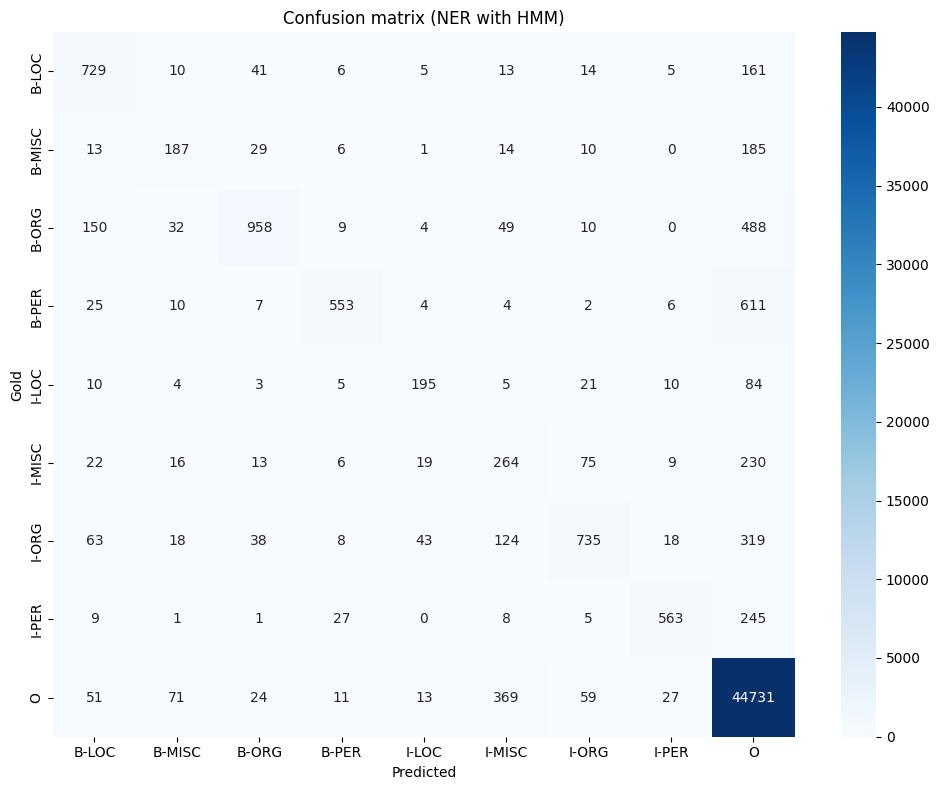

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_gold, all_pred, labels=labels)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels,
            cmap='Blues', ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Gold')
ax.set_title('Confusion matrix (NER with HMM)')
plt.tight_layout()
plt.show()

## Reflection

**What are the limitations of this model?**

- **Unknown words** (`<UNK>`) receive the same emission distribution regardless of context. A more sophisticated model could use morphological features (capitalization, suffixes, etc.).

- The HMM assumes that the probability of a word depends only on the current tag, not on neighboring words. More sophisticated models such as conditional random fields (CRFs) relax this assumption by allowing arbitrary features of the input.

- The model is generative: it models $P(x, y) = P(y) \cdot P(x \mid y)$. CRFs are discriminative and model $P(y \mid x)$ directly, which typically yields better results in classification tasks.